In [1]:
import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

### Function to Create a Network

In [23]:
def create_network(network_type, num_nodes, seed = None, p = 0.1, m = 5, k = 6):
    if network_type == 'Erdos-Reyni':
        return nx.erdos_renyi_graph(num_nodes, p, seed)
    elif network_type == 'Barabasi-Albert':
        return nx.barabasi_albert_graph(num_nodes, m, seed)
    elif network_type == 'Watts-Strogatz':
        return nx.watts_strogatz_graph(num_nodes, k, p, seed)
    else:
        raise ValueError("Invalid network type. Choose from 'Erdos-Reyni', 'Barabasi-Albert', or 'Watts-Strogatz'.")

### Function to Run the Simulation on an SIR Model 

In [5]:
# Function to run SIR simulation
def run_sir_simulation(network, beta, gamma, initial_infected_fraction, iterations=100):
    # Configuring the model
    model = ep.SIRModel(network)
    config = mc.Configuration()

    #Add model Parameters 
    config.add_model_parameter('beta', beta) 
    config.add_model_parameter('gamma', gamma)  
    config.add_model_parameter('percentage_infected', initial_infected_fraction)  # Initial infected population 
    model.set_initial_status(config)

    trends = model.iteration_bunch(iterations)

    susceptible = [trend['node_count'][0] for trend in trends]
    infected = [trend['node_count'][1] for trend in trends]
    recovered = [trend['node_count'][2] for trend in trends]

    return susceptible, infected, recovered

### Function to Plot SIR Results

In [7]:
# Function to plot SIR curves for all combinations of beta and gamma
def plot_sir_results(results):
    num_plots = len(results)
    cols = 3  # Number of columns in the plot grid
    rows = (num_plots // cols) + (num_plots % cols > 0)  # Calculate number of rows needed
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()  # Flatten the axes array to easily iterate through it

    for idx, ((beta, gamma), (susceptible, infected, recovered)) in enumerate(results.items()):
        ax = axes[idx]
        ax.plot(susceptible, label='Susceptible', color='blue')
        ax.plot(infected, label='Infected', color='red')
        ax.plot(recovered, label='Recovered', color='green')

        ax.set_title(f"Beta: {beta}, Gamma: {gamma}")
        ax.set_xlabel('Iterations')
        ax.set_ylabel('Population')
        ax.legend()

    # Hide any unused subplots
    for idx in range(len(results), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

### Function to Run Experiments with Varying Parameters

In [37]:
# Function to run experiments with varying parameters
def experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Reyni', num_nodes=100, initial_infected_fraction=0.01, iterations=100):
    results = {}

    # Create the network
    network = create_network(network_type, num_nodes, p = 0.1, seed = 10)

    # Run SIR simulations for all combinations of beta and gamma
    for beta in beta_values:
        for gamma in gamma_values:
            susceptible, infected, recovered = run_sir_simulation(network, beta, gamma, initial_infected_fraction, iterations)
            results[(beta, gamma)] = (susceptible, infected, recovered)

            plt.plot(infected, label=f'Beta: {beta}, Gamma: {gamma}')
    
    plt.title(f'SIR Model on {network_type.capitalize()} Network')
    plt.xlabel('Iterations')
    plt.ylabel('Infected Count')
    plt.legend()
    plt.show()

    return results

### Running the Experiment on Different Parameters 

In [61]:
beta_values = np.linspace(0.1, 0.5, 2)  
gamma_values = np.linspace(0.1, 0.5, 2)  


results = experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Reyni', num_nodes=200, iterations=100)
plot_sir_results(results)

## 2.2 Generate Networks of equivalent form

Using NetworkX generate multiple model networks with similar characteristics, again
think about the parameters associated with each network generator (e.g., Number of
nodes, connection probability,etc). Pick some network statistics (e.g., centrality measures,
degree distributions, etc.) that are interesting to measure in terms of spreading on the
network. You should generate multiple instances of each network type and then plot the
network statistics (you chose) and discuss how these statistic differ between network types
and for different parameter settings. You will use these generated networks in your SIR
experiments in the next part.

In [173]:
# Get degree historgram and display it
def network_degree_histogram(network):
    degree_histogram = nx.degree_histogram(network)

    plt.hist(degree_histogram, edgecolor='black')

    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    plt.title('Degree Histogram')

    plt.show()

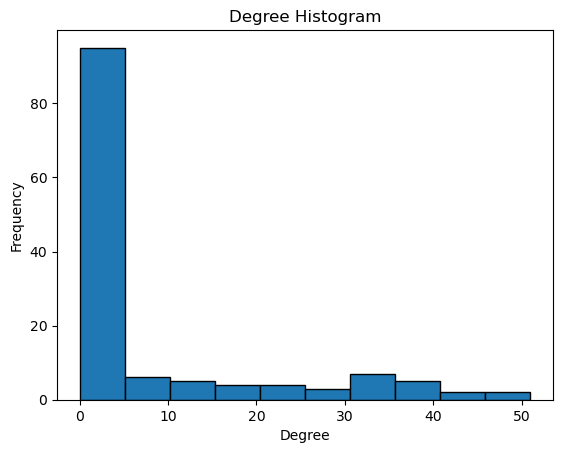

In [175]:
# Get statistics for one Erdos-Reyni network
num_nodes = 1000
 
network = create_network('Erdos-Reyni', num_nodes, seed = 10, p = 0.1)
network_degree_histogram(network)

## 2.3 Simulate SIR spread on the network

Simulate epidemic spreading on the networks you generated in the previous section
(NOTE: the simulations will be stochastic so think about random seeds and repitions).
You can vary the fraction of initial infected, which nodes are initially infected and other
disease parameters. Compare and discuss how the disease spreads in the different networks
under different conditions.

## 2.4 Dynamic Vaccination Campaign

Finally, we will conduct vaccination experiments using the sociopatterns dataset, see
Figure 1. You should design some code to load in the sociopatterns dataset (this file on
canvas includes a simple edgelist and NDLib and NetworkX provide ways to import this).

Now consider a scenario in which a disease is spreading on this network. You should run
multiple experiments, but assume that the disease always starts with a random selection
of 5 nodes infected.

You are to design a dynamic vaccination strategy in which you have a testing budget and
a limited number of vaccinations available per iteration of the model. Assume that you
have 200 tests in total, you can use a maximum number of tests per iteration (this will
vary per experiment see below), you can of course use less. You can use the tests at any
point during the spread and you may repeat tests on a node as often as you like. You
can assume that you know the network structure, but you can only discover the disease
status of a node after a test. Vaccinations can only be applied to susceptible people and
that they immediately move people to the removed state. Finally, you might consider
situations where the tests are not always accurate, but instead have some probability
(which you can vary) of being accurate. You can also assume that people remain removed
until the end of the simulation (no waning immunity).
You should compare your strategy against a simple null strategy which randomly assigns
vaccinations, you should design a strategy that at least out performs the null strategy.
Compare the strategies with different vaccination budgets of [1, 3, 5 and 10] per timestep
and compare with different testing accuracy [0.5, 0.75, 1.0] . Finally, keep in mind that
the purpose of the assignment is not to design the best strategy, but to evaluate you
strategy in a systematic and scientific manner.